In [2]:
from matplotlib.pyplot import plot

In [7]:
AVG_INTEREST = 0.07


def calcInterest(annual, freq):
    return annual/freq

def calcInvGrowth(start = 0, reimb = 0, freq = 1, annual = AVG_INTEREST, horizon = 1, fdp = 1):
    interest = calcInterest(annual, freq)
    ret = start
    inv = start

    res = []
    
    for i in range(horizon * freq):
        ret = (ret + reimb) * (1 + interest)
        inv += reimb

        if (i + 1) % (freq//fdp) == 0:
            res += [[round(inv, 4), round(ret, 4)]]

    return res

def savingCalc(start, reimb, horizon, freq = 12, fdp = 1):
    sav = start
    savData = []

    for i in range(freq*horizon):
        sav += reimb
        if (i + 1) % (freq//fdp) == 0:
            savData += [round(sav, 2)]

    return savData

def project(startI = 0, startS = 0, salary = 0, 
            freqI = 12, freqS = 12, annual = AVG_INTEREST, 
            horizon = 1, fDataPoints = 1, 
            rr = 0.10, rs = 0.10):
    
    reimb = rr * (salary / freqI)
    saving = rs * (salary / freqS)
    rest = (salary - reimb * freqI - saving * freqS)
    
    inv = calcInvGrowth(startI, reimb, freqI, annual, horizon, fDataPoints)
    savings = savingCalc(startS, saving, horizon, freqS, fDataPoints)

    assert(len(inv) == len(savings))
    
    res = []
    for i in range(len(inv)):
        net = savings[i] + inv[i][1]
        
        res += [[savings[i], inv[i], net, round(rest / 12, 2), round(1/fDataPoints, 10)]]

    return res

def findCoefficients(startInv = 0, 
                     startSave = 0, 
                     salaries = [],
                     t = [],
                     minRest = [],
                     minSave = []):

    optRR = [1] * len(t)
    optRS = [0] * len(t)
    delta = 0.00001

    prevSav = startInv
    prevInv = startSave
    for i in range(len(t)):
        maxNet = 0
        maxSav = 0
        maxInv = 0
        optRS[i] = (minSave[i] - prevSav) / (t[i] * salaries[i])
        for epoch in range(0, 100000):
            proj = project(prevInv, prevSav, salaries[i], 
                 12, 12, 
                 AVG_INTEREST, t[i], 1,
                 optRR[i], optRS[i])

            adj = proj[-1]

            maxSav = adj[0]
            maxInv = adj[1][1]

            if adj[3] < minRest[i]:
                optRR[i] += delta * (adj[3] - minRest[i])

        prevSav, prevInv = maxSav, maxInv

    for i in range(len(t)):
        optRR[i] = round(optRR[i], 4)
        optRS[i] = round(optRS[i], 4)
    return optRR, optRS

def projBasedOnOptimumParams(startInv = 0, 
                     startSave = 0, 
                     salaries = [],
                     t = [],
                     minRest = [],
                     minSave = [],
                     opt = True,
                     coef = [[0.10]*6, [0.10]*6],
                     freqOfDataPoints = 1):

    if opt:
        optRR, optRS = findCoefficients(startInv, startSave, salaries, t, minRest, minSave)
    else:
        optRR, optRS = coef
        
    print(optRR)
    print(optRS)

    prevSav = startInv
    prevInv = startSave
    result = []
    for i in range(len(t)):
        proj = project(prevInv, prevSav, salaries[i], 
                 12, 12, 
                 AVG_INTEREST, t[i], freqOfDataPoints,
                 optRR[i], optRS[i] )
        
        prevSav = proj[-1][0]
        prevInv = proj[-1][1][1]
        
        result += [proj]
        
    return result

def graphs(projs):
    sav = []
    inv = []
    net = []
    t = []
    for p in projs:
        for d in p:
            sav += [d[0]]
            inv += [d[1][1]]
            net += [d[0] + d[1][1]]
            t += [d[4]]

    for i in range(1, len(t)):
        t[i] = round(t[i] + t[i-1], 10)
    
    plot(t, sav)
    plot(t, inv)
    plot(t, net)

[0.0834, 0.7771, 0.1409, 0.1525, 0.1186, 0.1714]
[0.4167, 0.0729, 0.0496, 0.0652, 0.0678, 0.0377]


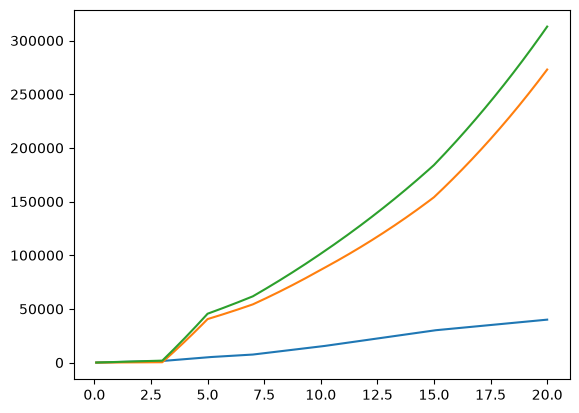

In [9]:
projs = projBasedOnOptimumParams(startInv = 0, 
                     startSave = 0, 
                     salaries = [1200, 24000, 36000 * 0.7, 65000 * 0.59, 75000 * 0.59, 90000*0.59],
                     t = [3, 2, 2, 3, 5, 5],
                     minRest = [50, 300, 1700, 2500, 3000, 3500],
                     minSave = [1500, 5000, 7500, 15000, 30000, 40000],
                     opt = True,
                     coef = [[0.10]*6, [0.10]*6],
                     freqOfDataPoints = 12)

graphs(projs)